In [375]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch
import torch.nn.functional as F
import numpy as np
from torchvision import models
from torchvision import transforms
from PIL import Image
from sklearn.calibration import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score
import pandas as pd



In [376]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [377]:
label_map = {0: "negative", 1: "nostalgic", 2: "positive"}

In [378]:
fold_number =1

## Load BERT model from HF

In [379]:

HF_MODEL_PATH = f"malgosielska/bert-emotion-classifier-fold-{fold_number}"

bert_tokenizer = RobertaTokenizer.from_pretrained(HF_MODEL_PATH)
bert_model = RobertaForSequenceClassification.from_pretrained(HF_MODEL_PATH)
bert_model.eval()

/Users/malgosielska/Studies/Sem 1 TAI/ML/Multimodal-classification/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=2)
      (position_embeddings): Embedding(514, 768, padding_idx=2)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

## Load CNN model

In [380]:
output_shape = 3
weights = models.RegNet_Y_800MF_Weights.DEFAULT # .DEFAULT = best available weights from pretraining on ImageNet

cnn_model = models.regnet_y_800mf(weights=weights)
cnn_model.fc = torch.nn.Linear(in_features=784,
                             out_features=output_shape, # same number of output units as our number of classes
                             bias=True)
cnn_model.load_state_dict(torch.load(f"../img_classification/RegNetTF_fold_{fold_number}.pth", map_location=device))
cnn_model.to(device)
cnn_model.eval()

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=4, bias=False)
            

In [381]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) 
])

## Wczytanie danych

In [382]:
lyrics_folder = "../dataset/Lyrics"
labels_file = "../dataset/classes.txt"
image_folder = "../dataset/spectograms/mel_graphic"
crossval_path = "../dataset/crossval_folds.csv"


In [383]:
all_labels = []
with open(labels_file, "r", encoding="utf-8") as f:
    all_labels = f.readlines()

all_labels = [label.strip() for label in all_labels]
print(len(all_labels))
all_labels[:10]

764


['negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative']

In [384]:
import os

lyric_files = [f for f in os.listdir(lyrics_folder) if f.lower().endswith(".txt")]
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(".png")]

texts = []
labels = []
images = []

for idx in range(1, 904):  # 001 to 903
    lyrics_filename = f"{idx:03}.txt"
    lyrics_filepath = os.path.join(lyrics_folder, lyrics_filename)

    image_filename = f"{idx:03}_mel.png"
    image_filepath = os.path.join(image_folder, image_filename)
    if os.path.exists(image_filepath) and os.path.exists(lyrics_filepath):
        with open(lyrics_filepath, "r", encoding="utf-8") as f:
            text = f.read().strip()
            texts.append(text)
            images.append(image_filepath)
            labels.append(all_labels[idx - 1])

print(f"Loaded {len(texts)} lyrics and {len(images)} images and {len(labels)} labels.")

texts[:10], labels[:10], images[:10],len(texts), len(lyric_files), len(images)

Loaded 764 lyrics and 764 images and 764 labels.


(["Mama he treats your daughter mean \nMama he treats your daughter mean \nMama he treats your daughter mean \nHe's the meanest man I've ever seen \n\nMama he treats me badly \nMakes me love him madly \nMama he takes my money \nMakes me call him honey \n\nMama he can't be trusted \nHe makes me so disgusted \nAll of my friends they don't understand \nWhat's the matter with this man \n\nI tell you mama he treats your daughter mean \nMama he treats your daughter mean \nMama he treats your daughter mean \nHe's the meanest man I've ever seen \n\nMama this man is lazy \nAlmost drives me crazy \nMama he makes me squeeze him \nStill my squeezes don't please him \n\nMama my heart is aching \nI believe it's breaking \nI've stood all that I can stand \nWhat's the matter with this man? \n\nI tell you Mama he treats your daughter mean \nMama he treats your daughter mean \nMama he treats your daughter mean \nHe's the meanest man I've ever seen",
  'I plopped down in my easy chair and turned on Chann

In [385]:
label_encoder = LabelEncoder()
label_ids = label_encoder.fit_transform(labels)

label_classes = label_encoder.classes_

for i, class_name in enumerate(label_classes):
    count = np.sum(label_ids == i)
    print(f"{class_name} (ID={i}): {count} przykładów")

label_classes

negative (ID=0): 170 przykładów
nostalgic (ID=1): 224 przykładów
positive (ID=2): 370 przykładów


array(['negative', 'nostalgic', 'positive'], dtype='<U9')

In [386]:
df_folds = pd.read_csv(crossval_path)
train_indices = df_folds[(df_folds["fold"] == fold_number) & (df_folds["split"] == "train")]["index"].tolist()
temp_test_indices = df_folds[(df_folds["fold"] == fold_number) & (df_folds["split"] == "test")]["index"].tolist()

In [387]:
train_texts = [texts[i] for i in train_indices]
train_labels = [label_ids[i] for i in train_indices]
train_images = [images[i] for i in train_indices]

test_texts = [texts[i] for i in temp_test_indices]
test_labels = [label_ids[i] for i in temp_test_indices]
test_images = [images[i] for i in temp_test_indices]

test_images

['../dataset/spectograms/mel_graphic/008_mel.png',
 '../dataset/spectograms/mel_graphic/010_mel.png',
 '../dataset/spectograms/mel_graphic/014_mel.png',
 '../dataset/spectograms/mel_graphic/025_mel.png',
 '../dataset/spectograms/mel_graphic/026_mel.png',
 '../dataset/spectograms/mel_graphic/027_mel.png',
 '../dataset/spectograms/mel_graphic/032_mel.png',
 '../dataset/spectograms/mel_graphic/036_mel.png',
 '../dataset/spectograms/mel_graphic/039_mel.png',
 '../dataset/spectograms/mel_graphic/046_mel.png',
 '../dataset/spectograms/mel_graphic/047_mel.png',
 '../dataset/spectograms/mel_graphic/051_mel.png',
 '../dataset/spectograms/mel_graphic/053_mel.png',
 '../dataset/spectograms/mel_graphic/058_mel.png',
 '../dataset/spectograms/mel_graphic/063_mel.png',
 '../dataset/spectograms/mel_graphic/072_mel.png',
 '../dataset/spectograms/mel_graphic/076_mel.png',
 '../dataset/spectograms/mel_graphic/083_mel.png',
 '../dataset/spectograms/mel_graphic/085_mel.png',
 '../dataset/spectograms/mel_gr

# 1: Weighted Voting Fusion Function

In [388]:
def predict_emotion(text, spectrogram_path, weights):
    # --- BERT prediction (probabilities) ---
    inputs = bert_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        logits_bert = bert_model(**inputs).logits
        probs_bert = torch.softmax(logits_bert, dim=-1).squeeze().cpu().numpy()

    # --- CNN prediction (probabilities) ---
    image = Image.open(spectrogram_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits_cnn = cnn_model(image_tensor)
        probs_cnn = torch.softmax(logits_cnn, dim=-1).squeeze().cpu().numpy()

    # --- Weighted average of probabilities ---
    final_probs = weights[0] * probs_bert + weights[1] * probs_cnn
    final_pred = int(np.argmax(final_probs))

    return final_pred

In [389]:
text_input = "Mama he treats your daughter mean"
spectrogram_path = "../dataset/spectograms/mel_graphic/001_mel.png"

label = predict_emotion(text_input, spectrogram_path, (0.6, 0.4))
print("Predicted Emotion:", label)


Predicted Emotion: 2


In [390]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

best_acc = 0.0
best_weights = (0.5, 0.5)
results = []

for w_bert in np.arange(0.0, 1.1, 0.1):
    w_cnn = 1.0 - w_bert
    y_true = []
    y_pred = []

    for text, image_path, label in zip(test_texts, test_images, test_labels):
        pred = predict_emotion(text, image_path, (w_bert, w_cnn))
        y_true.append(label)
        y_pred.append(pred)

    bal_acc = balanced_accuracy_score(y_true, y_pred)

    results.append({
        "w_BERT": round(w_bert, 2),
        "w_CNN": round(w_cnn, 2),
        "balanced_accuracy": round(bal_acc, 4),
    })

    if bal_acc > best_acc:
        best_acc = bal_acc
        best_weights = (w_bert, w_cnn)

# Wyniki w tabeli
results_df = pd.DataFrame(results)
print(results_df)

print(f"\nBest balanced accuracy: {best_acc:.4f} with weights BERT={best_weights[0]}, CNN={best_weights[1]}")


    w_BERT  w_CNN  balanced_accuracy
0      0.0    1.0             0.6287
1      0.1    0.9             0.6451
2      0.2    0.8             0.6541
3      0.3    0.7             0.6766
4      0.4    0.6             0.6713
5      0.5    0.5             0.6864
6      0.6    0.4             0.6729
7      0.7    0.3             0.6639
8      0.8    0.2             0.6586
9      0.9    0.1             0.6369
10     1.0    0.0             0.6393

Best balanced accuracy: 0.6864 with weights BERT=0.5, CNN=0.5


In [391]:
y_true = []
y_pred = []

for text, image_path, label in zip(test_texts, test_images, test_labels):
    pred = predict_emotion(text, image_path, (round(best_weights[0], 2),round(best_weights[1], 2))) 
    y_true.append(label)
    y_pred.append(pred)


Accuracy: 0.673202614379085
Accuracy balanced: 0.6864393805570277
F1 weighted: 0.6743642592299415
F1 macro: 0.6697983598967413
Classification report:
               precision    recall  f1-score   support

    negative       0.58      0.74      0.65        34
   nostalgic       0.66      0.69      0.67        45
    positive       0.75      0.64      0.69        74

    accuracy                           0.67       153
   macro avg       0.66      0.69      0.67       153
weighted avg       0.68      0.67      0.67       153



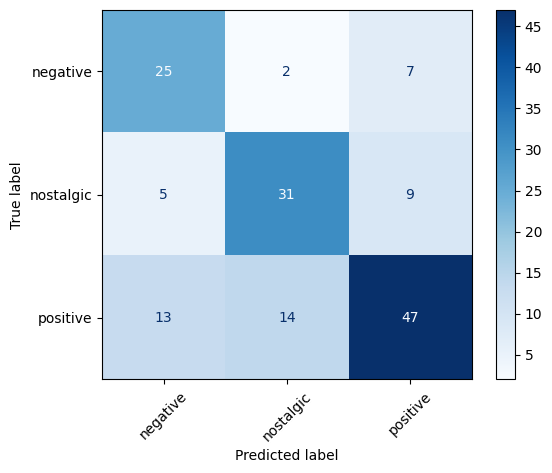

In [392]:
acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted') 
f1_macro = f1_score(y_true, y_pred, average='macro') 

print("Accuracy:", acc)
print("Accuracy balanced:", bal_acc)
print("F1 weighted:", f1)
print("F1 macro:", f1_macro)

print("Classification report:\n", classification_report(y_true, y_pred, target_names=label_encoder.classes_))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=label_encoder.classes_
)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

# 2: Stacking

In [393]:
def get_bert_probs(text):
    inputs = bert_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        logits = bert_model(**inputs).logits
    return F.softmax(logits, dim=-1).squeeze().cpu().numpy()

def get_cnn_probs(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = cnn_model(image_tensor)
    return F.softmax(logits, dim=-1).squeeze().cpu().numpy()


In [394]:
X_meta = []
y_meta = []

for text, image_path, label in zip(train_texts, train_images, train_labels):
    probs_bert = get_bert_probs(text)
    probs_cnn = get_cnn_probs(image_path)
    features = np.concatenate([probs_bert, probs_cnn]) 
    X_meta.append(features)
    y_meta.append(label)


In [395]:
meta_clf = LogisticRegression(max_iter=1000)
meta_clf.fit(X_meta, y_meta)

/Users/malgosielska/Studies/Sem 1 TAI/ML/Multimodal-classification/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/malgosielska/Studies/Sem 1 TAI/ML/Multimodal-classification/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/malgosielska/Studies/Sem 1 TAI/ML/Multimodal-classification/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/malgosielska/Studies/Sem 1 TAI/ML/Multimodal-classification/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in

LogisticRegression(max_iter=1000)

In [396]:
y_pred = []
y_true = []

for text, image_path, label in zip(test_texts, test_images, test_labels):
    probs_bert = get_bert_probs(text)
    probs_cnn = get_cnn_probs(image_path)
    features = np.concatenate([probs_bert, probs_cnn]).reshape(1, -1)

    pred = meta_clf.predict(features)[0]
    y_pred.append(pred)
    y_true.append(label)

Accuracy: 0.7124183006535948
Balanced Accuracy: 0.6836
Classification report:
               precision    recall  f1-score   support

    negative       0.72      0.62      0.67        34
   nostalgic       0.74      0.62      0.67        45
    positive       0.70      0.81      0.75        74

    accuracy                           0.71       153
   macro avg       0.72      0.68      0.70       153
weighted avg       0.72      0.71      0.71       153



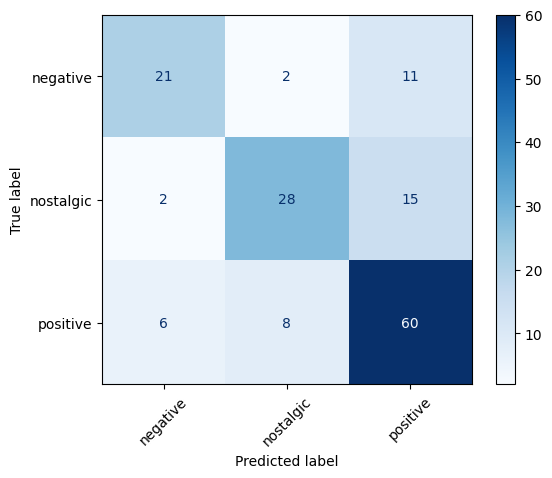

In [397]:
print("Accuracy:", accuracy_score(y_true, y_pred))
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("Classification report:\n", classification_report(y_true, y_pred, target_names=label_encoder.classes_))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=label_encoder.classes_
)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()


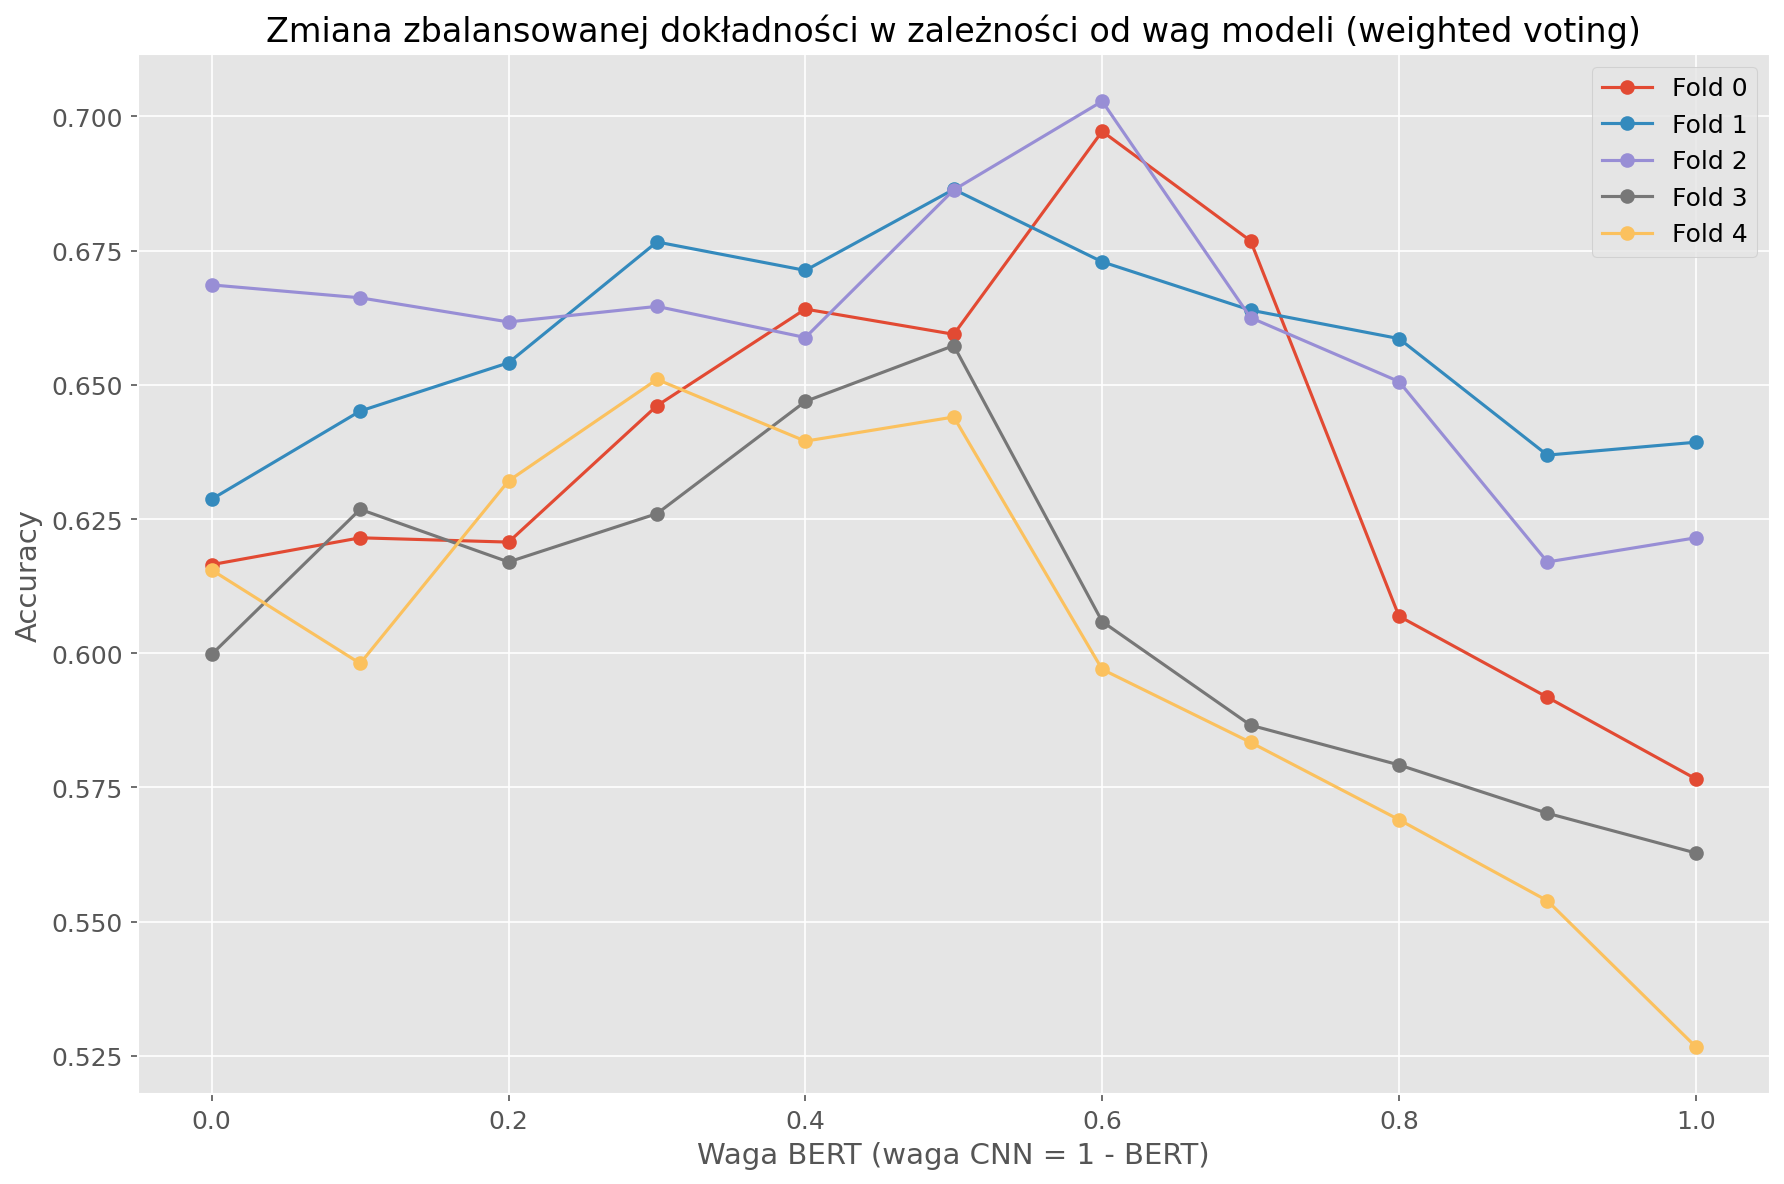

In [14]:
import matplotlib.pyplot as plt

# Wagi BERT (waga CNN = 1 - waga BERT)
bert_weights = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Accuracy dla każdego folda
fold_accuracies = {
    "Fold 0": [0.6165, 0.6215, 0.6207, 0.6461, 0.6641, 0.6594, 0.6972, 0.6768, 0.6069, 0.5918, 0.5766],
    "Fold 1": [0.6287, 0.6451, 0.6541, 0.6766, 0.6713, 0.6864, 0.6729, 0.6639, 0.6586, 0.6369, 0.6393],
    "Fold 2": [0.6686, 0.6662, 0.6617, 0.6646, 0.6588, 0.6863, 0.7028, 0.6625, 0.6506, 0.6170, 0.6215],
    "Fold 3": [0.5998, 0.6268, 0.6170, 0.6260, 0.6469, 0.6573, 0.6059, 0.5866, 0.5792, 0.5702, 0.5628],
    "Fold 4": [0.6155, 0.5981, 0.6321, 0.6510, 0.6395, 0.6440, 0.5970, 0.5834, 0.5690, 0.5539, 0.5267]
}

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8), dpi=150)  # większy rozmiar i wyższa rozdzielczość
for fold, acc in fold_accuracies.items():
    plt.plot(bert_weights, acc, marker='o', label=fold)

plt.xlabel("Waga BERT (waga CNN = 1 - BERT)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Zmiana zbalansowanej dokładności w zależności od wag modeli (weighted voting)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()



## Charts

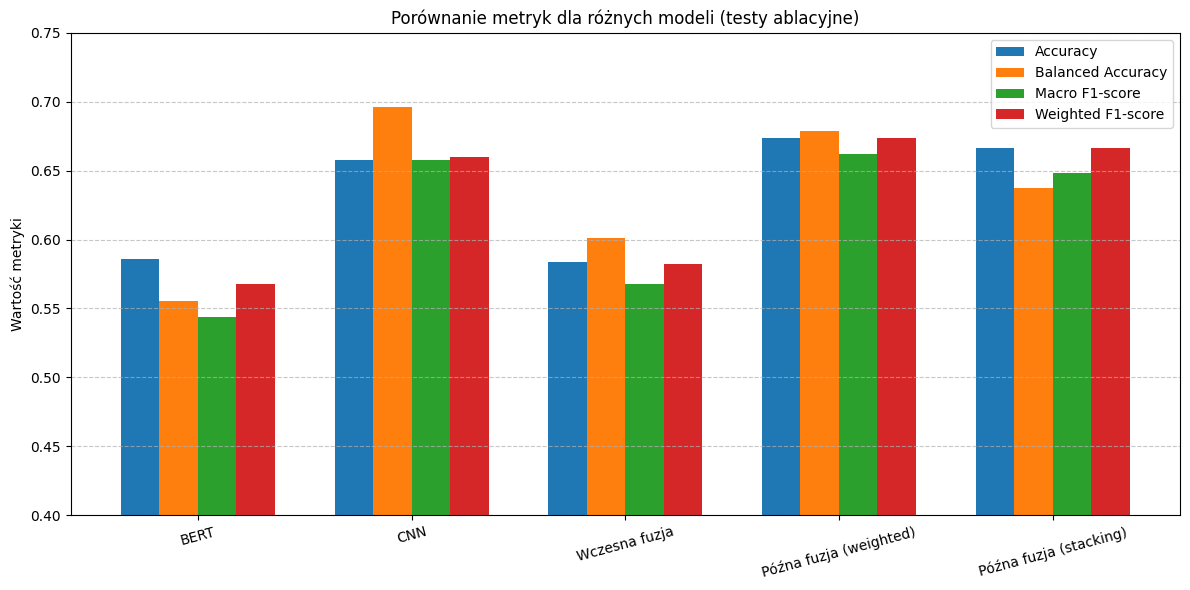

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nazwy modeli
models = ["BERT", "CNN", "Wczesna fuzja", "Późna fuzja\n(weighted)", "Późna fuzja\n(stacking)"]

# Metryki
accuracy = [0.5860, 0.6580, 0.5840, 0.6740, 0.6667]
balanced_accuracy = [0.5552, 0.6960, 0.6013, 0.6789, 0.6374]
macro_f1 = [0.5440, 0.6580, 0.5680, 0.6620, 0.6480]
weighted_f1 = [0.5680, 0.6600, 0.5820, 0.6740, 0.6666]

# Pozycje słupków
x = np.arange(len(models))
width = 0.2

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(14, 6))

# Rysowanie słupków
ax.bar(x - 1.5 * width, accuracy, width, label="Accuracy")
ax.bar(x - 0.5 * width, balanced_accuracy, width, label="Balanced Acc.")
ax.bar(x + 0.5 * width, macro_f1, width, label="Macro F1")
ax.bar(x + 1.5 * width, weighted_f1, width, label="Weighted F1")

# Etykiety
ax.set_ylabel("Wartość metryki", fontsize=14)
ax.set_xlabel("Model", fontsize=14)
ax.set_title("Porównanie metryk dla różnych wariantów modelu", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
plt.yticks(fontsize=12)

# Przeniesienie legendy poza wykres
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Lepszy układ i zapis
plt.tight_layout(rect=[0, 0, 0.85, 1])  # zostawia miejsce na legendę z prawej
plt.savefig("metrics_comp.png", dpi=300, bbox_inches='tight')
plt.show()
